# Sahayak Triage — Phase 1: Model Training and Evaluation

This notebook loads the cleaned fever/infection triage dataset, trains a LightGBM multi-class classifier to predict the urgency score (ESI 1-5), evaluates the model performance (paying special attention to safety-critical metrics like recall on high-urgency cases), and computes feature importances using SHAP values.

## 1. Import Packages

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score
import shap
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\sriji\Projects\Sahayak Triage\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Cleaned Dataset

In [2]:
processed_path = "../data/processed/cleaned_triage_data.csv"
print("Loading cleaned dataset...")
df = pd.read_csv(processed_path)
print(f"Dataset shape: {df.shape}")

Loading cleaned dataset...


Dataset shape: (64132, 44)


## 3. Split Features and Target

We drop the target variable `esi` and map it from 1-5 to 0-4 to fit LightGBM's 0-indexed multiclass expectations.

In [3]:
target_col = 'esi'
X = df.drop(columns=[target_col])
y = df[target_col] - 1

print(f"Number of features: {X.shape[1]}")
print("Feature list:", list(X.columns))

Number of features: 43
Feature list: ['age', 'gender', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_temp', 'cc_breathingdifficulty', 'cc_breathingproblem', 'cc_chills', 'cc_coldlikesymptoms', 'cc_cough', 'cc_fever', 'cc_fever-75yearsorolder', 'cc_fever-9weeksto74years', 'cc_feverimmunocompromised', 'cc_nasalcongestion', 'cc_respiratorydistress', 'cc_shortnessofbreath', 'cc_sorethroat', 'cc_unresponsive', 'cc_urinarytractinfection', 'cc_woundinfection', 'triage_vital_hr_is_missing', 'triage_vital_sbp_is_missing', 'triage_vital_dbp_is_missing', 'triage_vital_rr_is_missing', 'triage_vital_o2_is_missing', 'triage_vital_temp_is_missing', 'qsofa_rr_high', 'qsofa_sbp_low', 'qsofa_altered_mental', 'qsofa_score', 'sirs_temp_abnormal', 'sirs_hr_high', 'sirs_rr_high', 'sirs_score', 'shock_index', 'pulse_pressure', 'hypoxia_severe', 'hypoxia_moderate', 'age_elderly']


## 4. Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 51305, Test size: 12827


## 5. Train LightGBM Multiclass Classifier

In [5]:
print("Training LightGBM classifier with custom weights...")
params = {
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': 6,
    'feature_fraction': 0.8,
    'min_child_samples': 50,
    'random_state': 42,
    'verbose': -1
}

custom_weights = {0: 10.0, 1: 2.0, 2: 1.0, 3: 1.0, 4: 2.0}
sample_weight = y_train.map(custom_weights).values

train_data = lgb.Dataset(X_train, label=y_train, weight=sample_weight)
val_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

model = lgb.train(
    params,
    train_data,
    num_boost_round=400,
    valid_sets=[train_data, val_data],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

Training LightGBM classifier with custom weights...


Training until validation scores don't improve for 50 rounds


[50]	training's multi_logloss: 0.925206	valid_1's multi_logloss: 1.00457


[100]	training's multi_logloss: 0.850729	valid_1's multi_logloss: 0.945149


[150]	training's multi_logloss: 0.822077	valid_1's multi_logloss: 0.926765


[200]	training's multi_logloss: 0.806811	valid_1's multi_logloss: 0.919271


[250]	training's multi_logloss: 0.79572	valid_1's multi_logloss: 0.915631


[300]	training's multi_logloss: 0.785751	valid_1's multi_logloss: 0.913607


[350]	training's multi_logloss: 0.77627	valid_1's multi_logloss: 0.912307


[400]	training's multi_logloss: 0.767377	valid_1's multi_logloss: 0.911728
Did not meet early stopping. Best iteration is:
[398]	training's multi_logloss: 0.767667	valid_1's multi_logloss: 0.911725


## 6. Model Evaluation

We evaluate overall metrics and confusion matrix. We pay special attention to **Recall on ESI 1 (Highest Urgency)** and **Recall on ESI 2 (High Urgency)**.

In [6]:
def predict_with_overrides(model, X_df):
    """
    Predict ESI class (0-4) with clinical safety overrides applied.
    0 -> ESI 1 (Highest Urgency)
    1 -> ESI 2 (High Urgency)
    2 -> ESI 3 (Medium Urgency)
    3 -> ESI 4 (Low Urgency)
    4 -> ESI 5 (Lowest Urgency)
    """
    y_pred_probs = model.predict(X_df)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    y_pred_override = []
    for idx, (pred, (_, row)) in enumerate(zip(y_pred, X_df.iterrows())):
        # 1. ESI 1 Overrides (Immediate Life Saving Intervention)
        is_unresponsive = row.get('cc_unresponsive', 0) == 1
        is_resp_distress = row.get('cc_respiratorydistress', 0) == 1
        o2 = row.get('triage_vital_o2', np.nan)
        is_severely_hypoxic = not np.isnan(o2) and o2 < 90
        
        if is_unresponsive or is_resp_distress or is_severely_hypoxic:
            y_pred_override.append(0)  # ESI 1
            continue
            
        # 2. ESI 2 Overrides (Emergent)
        # Calculate qSOFA
        rr = row.get('triage_vital_rr', np.nan)
        sbp = row.get('triage_vital_sbp', np.nan)
        qsofa = 0
        if not np.isnan(rr) and rr >= 22:
            qsofa += 1
        if not np.isnan(sbp) and sbp <= 100:
            qsofa += 1
        if is_unresponsive:
            qsofa += 1
            
        # If qSOFA >= 2, moderate hypoxia (SpO2 < 95), or extreme temperature (>104 or <95)
        # and predicted class is lower urgency than ESI 2 (i.e. ESI 3, 4, 5) -> upgrade to ESI 2 (1)
        temp = row.get('triage_vital_temp', np.nan)
        is_moderately_hypoxic = not np.isnan(o2) and o2 < 95
        is_temp_extreme = not np.isnan(temp) and (temp > 104 or temp < 95)
        
        is_high_risk = (qsofa >= 2) or is_moderately_hypoxic or is_temp_extreme
        
        if is_high_risk and pred > 1:
            y_pred_override.append(1)  # ESI 2
        else:
            y_pred_override.append(pred)
            
    return np.array(y_pred_override)

# Predictions
print("\n--- Evaluating Baseline Model ---")
y_pred_probs = model.predict(X_test)
y_pred_base = np.argmax(y_pred_probs, axis=1)

accuracy_base = accuracy_score(y_test, y_pred_base)
print(f"Accuracy: {accuracy_base:.4f}")

target_names = [f"ESI {i}" for i in range(1, 6)]
print("\nClassification Report (Baseline):")
print(classification_report(y_test, y_pred_base, target_names=target_names))

recall_esi1_base = recall_score(y_test, y_pred_base, labels=[0], average='macro')
recall_esi2_base = recall_score(y_test, y_pred_base, labels=[1], average='macro')
print(f"Recall on ESI 1 (Highest Urgency): {recall_esi1_base:.4f}")
print(f"Recall on ESI 2 (High Urgency): {recall_esi2_base:.4f}")

# Predictions with overrides
print("\n--- Evaluating Model with Clinical Overrides ---")
y_pred_override = predict_with_overrides(model, X_test)

accuracy_override = accuracy_score(y_test, y_pred_override)
print(f"Accuracy: {accuracy_override:.4f}")

print("\nClassification Report (With Clinical Overrides):")
print(classification_report(y_test, y_pred_override, target_names=target_names))

recall_esi1_override = recall_score(y_test, y_pred_override, labels=[0], average='macro')
recall_esi2_override = recall_score(y_test, y_pred_override, labels=[1], average='macro')
print(f"Recall on ESI 1 (Highest Urgency): {recall_esi1_override:.4f}")
print(f"Recall on ESI 2 (High Urgency): {recall_esi2_override:.4f}")

# Overrides count
changed_count = (y_pred_base != y_pred_override).sum()
print(f"\nNumber of overridden predictions: {changed_count} ({changed_count/len(y_test):.2%})")

# 3-Class mapped evaluation
print("\n--- Evaluating Hybrid Model on 3-Class Referral Tiers ---")
y_test_3class = pd.Series(y_test).map({0: 0, 1: 0, 2: 1, 3: 2, 4: 2})
y_pred_3class = pd.Series(y_pred_override).map({0: 0, 1: 0, 2: 1, 3: 2, 4: 2})

print(f"3-Class Tier Accuracy: {accuracy_score(y_test_3class, y_pred_3class):.4f}")
print("\nClassification Report (3-Class Tiers):")
print(classification_report(y_test_3class, y_pred_3class, target_names=["High Urgency (ESI 1-2)", "Medium Urgency (ESI 3)", "Low Urgency (ESI 4-5)"]))


--- Evaluating Baseline Model ---


Accuracy: 0.6060

Classification Report (Baseline):
              precision    recall  f1-score   support

       ESI 1       0.46      0.53      0.49       230
       ESI 2       0.61      0.85      0.71      4269
       ESI 3       0.64      0.41      0.50      4909
       ESI 4       0.65      0.61      0.63      2626
       ESI 5       0.42      0.54      0.47       793

    accuracy                           0.61     12827
   macro avg       0.56      0.59      0.56     12827
weighted avg       0.61      0.61      0.59     12827

Recall on ESI 1 (Highest Urgency): 0.5304
Recall on ESI 2 (High Urgency): 0.8468

--- Evaluating Model with Clinical Overrides ---


Accuracy: 0.5836

Classification Report (With Clinical Overrides):
              precision    recall  f1-score   support

       ESI 1       0.27      0.59      0.37       230
       ESI 2       0.58      0.81      0.68      4269
       ESI 3       0.64      0.38      0.48      4909
       ESI 4       0.65      0.61      0.63      2626
       ESI 5       0.42      0.54      0.47       793

    accuracy                           0.58     12827
   macro avg       0.51      0.58      0.52     12827
weighted avg       0.60      0.58      0.57     12827

Recall on ESI 1 (Highest Urgency): 0.5870
Recall on ESI 2 (High Urgency): 0.8082

Number of overridden predictions: 454 (3.54%)

--- Evaluating Hybrid Model on 3-Class Referral Tiers ---
3-Class Tier Accuracy: 0.6593

Classification Report (3-Class Tiers):
                        precision    recall  f1-score   support

High Urgency (ESI 1-2)       0.62      0.89      0.73      4499
Medium Urgency (ESI 3)       0.64      0.38      0.48     

## 7. Plot Confusion Matrix

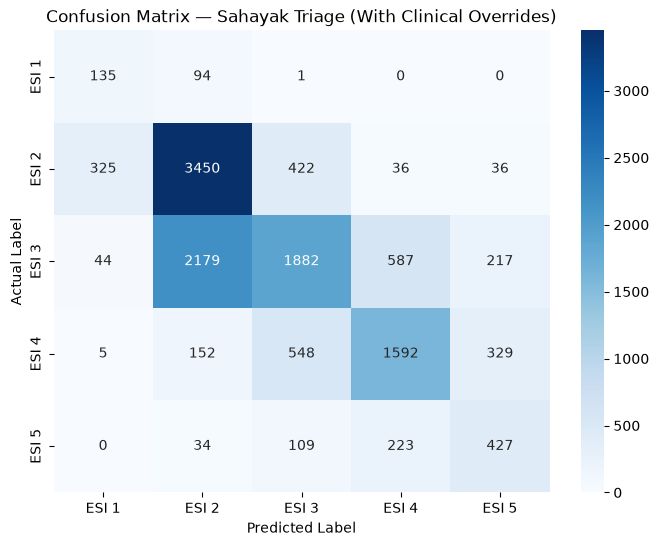

In [7]:
cm = confusion_matrix(y_test, y_pred_override)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix — Sahayak Triage (With Clinical Overrides)')
plt.show()

## 8. Feature Explanations via SHAP

Computing SHAP values...


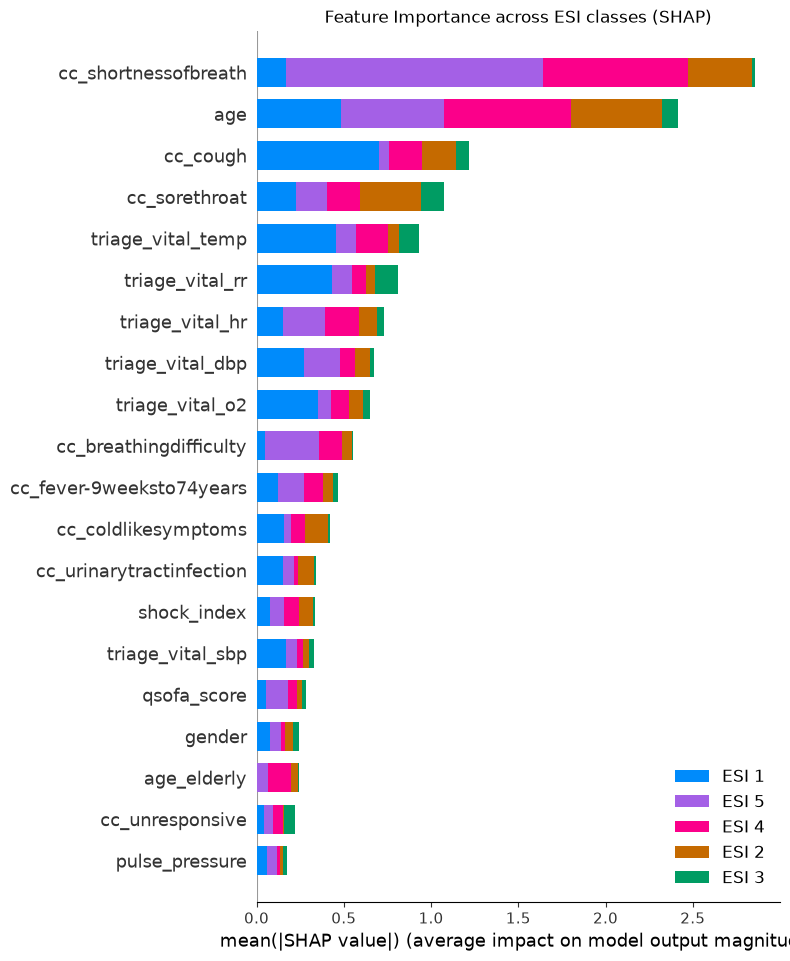

In [8]:
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
X_test_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# Plot summary plot (overall feature importance)
# Note: shap_values is a list for multiclass, index 0 corresponds to ESI 1
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", class_names=target_names, show=False)
plt.title("Feature Importance across ESI classes (SHAP)")
plt.show()

## 9. Save Model and Metadata

In [9]:
model_dir = "../src"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "triage_model.txt")
model.save_model(model_path)
print(f"Model saved to {model_path}")

feature_cols_path = os.path.join(model_dir, "feature_columns.pkl")
with open(feature_cols_path, 'wb') as f:
    pickle.dump(list(X.columns), f)
print(f"Feature columns saved to {feature_cols_path}")

Model saved to ../src\triage_model.txt
Feature columns saved to ../src\feature_columns.pkl
